In [10]:
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

In [11]:
with open("../../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

train_latents = train["latents"]
train_recon   = train["recon"]
train_re      = train["re"]

val_latents   = val["latents"]
val_recon     = val["recon"]
val_re        = val["re"]

kaon_latents  = kaon["latents"]
kaon_recon    = kaon["recon"]
kaon_re       = kaon["re"]

In [12]:
features = pd.read_pickle('/Volumes/easystore/proton-kaon/features/features.pkl')
index = np.load('/Volumes/easystore/proton-kaon/training/split_p.npz')

train_features = features[features['particle_type'] == 'proton'].iloc[index['train_idx']]
val_features = features[features['particle_type'] == 'proton'].iloc[index['val_idx']]
kaon_features = features[features['particle_type'] == 'kaon']

In [13]:
# ── align latents with features ────────────────────────────────────────
all_proton_features = features[features['particle_type'] == 'proton']
all_kaon_features   = features[features['particle_type'] == 'kaon']

latent_z = np.zeros((len(features), 4))
latent_z[all_proton_features.index[index['train_idx']], :] = train_latents
latent_z[all_proton_features.index[index['val_idx']], :] = val_latents
latent_z[all_kaon_features.index, :] = kaon_latents

features['z0'], features['z1'], features['z2'], features['z3'] = latent_z.T

In [14]:
# ── define feature groups (only available ones) ────────────────────────
calorimetry = [
    # image-based
    'total_adc', 'mean_adc', 'median_adc', 'max_adc', 'std_adc', 'adc_entropy',
    # column_maxes profile — intensity
    'bragg_peak_height', 'bragg_peak_position', 'bragg_peak_ratio', 'bragg_peak_to_median',
    'end_vs_start_ratio', 'last_quartile_mean', 'first_quartile_mean',
    'bragg_rise_slope', 'peak_integral_fraction', 'bragg_peak_width',
    'profile_cv', 'monotonic_rise_fraction', 'relative_peak_energy',
    # from topology.py but ADC-value based
    'profile_skewness', 'profile_kurtosis',
]

topology = [
    # bbox columns already in col
    'height', 'width',
    # computed
    'n_pixels', 'fill_fraction', 'solidity', 'n_local_maxima',
]

calorimetry = [f for f in calorimetry if f in features.columns]
topology = [f for f in topology if f in features.columns]
features_of_interest = calorimetry + topology
latents = ['z0', 'z1', 'z2', 'z3']

In [15]:
# ── compute Spearman correlations ──────────────────────────────────────
corr_matrix = np.zeros((len(features_of_interest), len(latents)))

for i, feat in enumerate(features_of_interest):
    for j, lat in enumerate(latents):
        valid = features[[feat, lat]].notna().all(axis=1)
        if valid.sum() > 2:
            rho, _ = spearmanr(features.loc[valid, feat], features.loc[valid, lat])
            corr_matrix[i, j] = rho

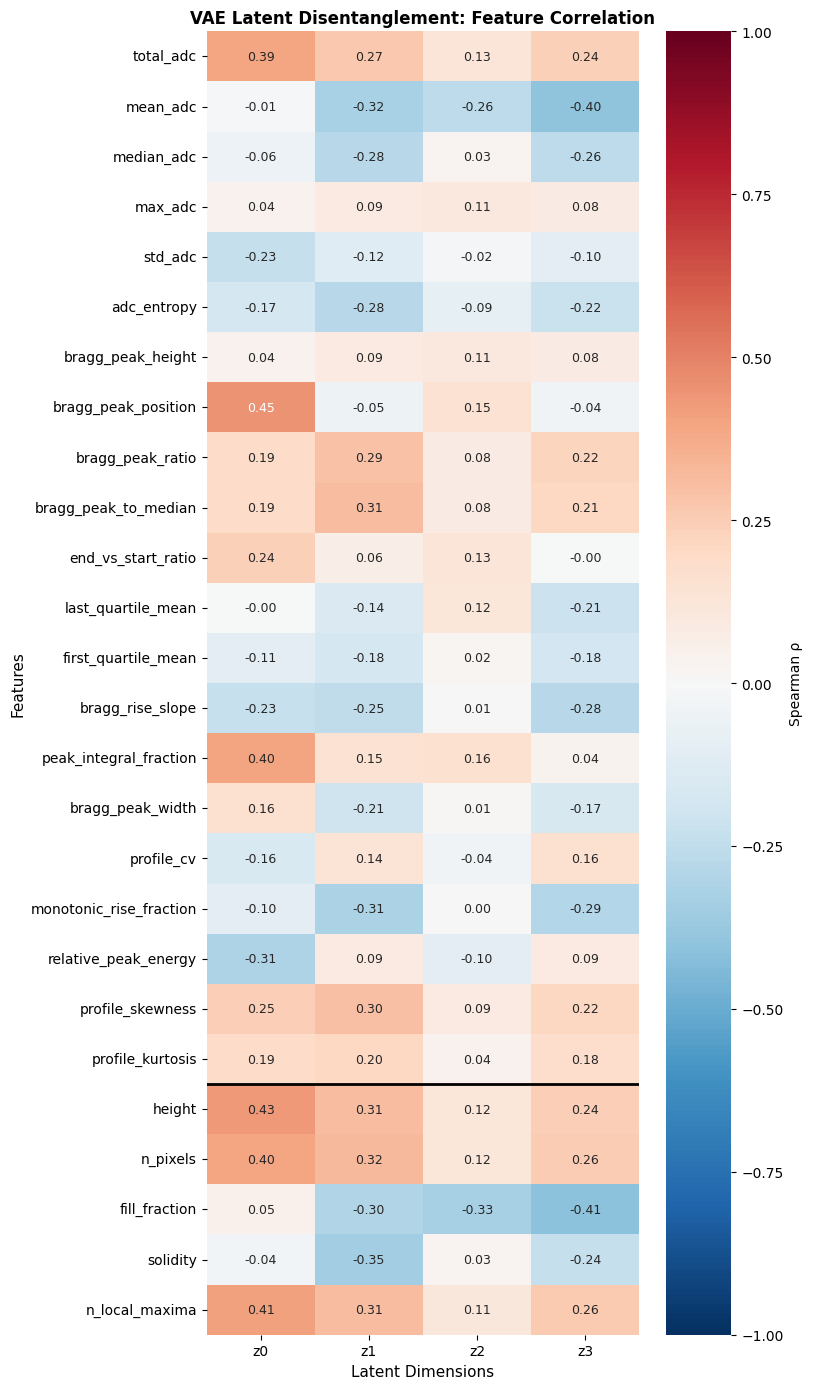

In [16]:
# ── plot heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 14))

sns.heatmap(corr_matrix,
            xticklabels=latents,
            yticklabels=features_of_interest,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Spearman ρ'},
            annot=True, fmt='.2f', annot_kws={'size': 9},
            ax=ax)

sep_y = len(calorimetry)
ax.axhline(y=sep_y, color='black', linewidth=2)

ax.set_title('VAE Latent Disentanglement: Feature Correlation', fontsize=12, weight='bold')
ax.set_xlabel('Latent Dimensions', fontsize=11)
ax.set_ylabel('Features', fontsize=11)

plt.tight_layout()
plt.savefig('../../figs/latents-features/disentanglement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ── summary ────────────────────────────────────────────────────────────
for j, lat in enumerate(latents):
    calo = np.abs(corr_matrix[:len(calorimetry), j])
    topo = np.abs(corr_matrix[len(calorimetry):, j])
    print(f"{lat}: calo mean |ρ|={calo.mean():.3f}, topo mean |ρ|={topo.mean():.3f}, specificity={calo.mean()/topo.mean():.2f}x")

z0: calo mean |ρ|=0.188, topo mean |ρ|=0.265, specificity=0.71x
z1: calo mean |ρ|=0.197, topo mean |ρ|=0.319, specificity=0.62x
z2: calo mean |ρ|=0.085, topo mean |ρ|=0.142, specificity=0.60x
z3: calo mean |ρ|=0.175, topo mean |ρ|=0.282, specificity=0.62x


category  calorimetry  topology
dim                            
z0             0.0238    0.0406
z1             0.0382    0.1001
z2             0.0057    0.0200
z3             0.0211    0.0673


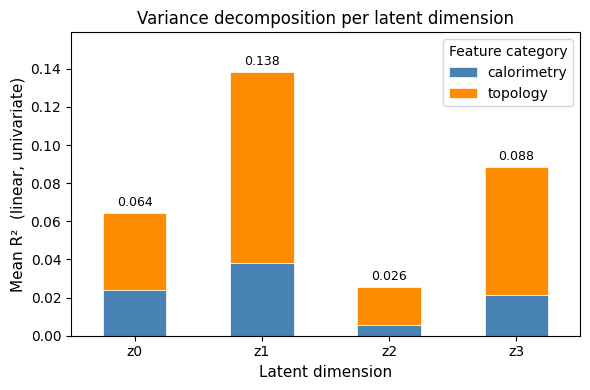

In [23]:
# ── feature groups ────────────────────────────────────────────────────────────
CALO = [
    # image-based
    'total_adc', 'mean_adc', 'median_adc', 'max_adc', 'std_adc', 'adc_entropy',
    # column_maxes profile — intensity
    'bragg_peak_height', 'bragg_peak_position', 'bragg_peak_ratio', 'bragg_peak_to_median',
    'end_vs_start_ratio', 'last_quartile_mean', 'first_quartile_mean',
    'bragg_rise_slope', 'peak_integral_fraction', 'bragg_peak_width',
    'profile_cv', 'monotonic_rise_fraction', 'relative_peak_energy',
    # from topology.py but ADC-value based
    'profile_skewness', 'profile_kurtosis',
]

TOPO = [
    # bbox columns already in col
    'height',
    # computed
    'n_pixels', 'fill_fraction', 'solidity', 'n_local_maxima',
]

# ── inputs ────────────────────────────────────────────────────────────────────
# latents: (N, 4) numpy array of posterior means from train.npz
# features_df: DataFrame with columns matching CALO + TOPO, indexed same as latents

all_features = CALO + TOPO
latents = features[['z0', 'z1', 'z2', 'z3']].values 

n_dims = latents.shape[1]

# ── per (z_i, feature) univariate linear R² ───────────────────────────────────
records = []

for i in range(n_dims):
    z = latents[:, i].reshape(-1, 1)

    for feat in all_features:
        y = features[feat].values
        mask = np.isfinite(y)                          # drop NaN / inf
        if mask.sum() < 10:
            continue

        r2 = LinearRegression().fit(z[mask], y[mask]).score(z[mask], y[mask])
        r2 = max(r2, 0.0)                              # clip: R² < 0 means worse than predicting mean

        records.append({
            'dim':      f'z{i}',
            'feature':  feat,
            'r2':       r2,
            'category': 'calorimetry' if feat in CALO else 'topology',
        })

results = pd.DataFrame(records)

# ── mean R² per dimension per category ───────────────────────────────────────
summary = (
    results
    .groupby(['dim', 'category'])['r2']
    .mean()
    .unstack('category')
    [['calorimetry', 'topology']]      # fix column order
)

print(summary.round(4))

# ── stacked bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

summary.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['steelblue', 'darkorange'],
    edgecolor='white',
    linewidth=0.5,
    width=0.5,
)

ax.set_xlabel('Latent dimension', fontsize=11)
ax.set_ylabel('Mean R²  (linear, univariate)', fontsize=11)
ax.set_title('Variance decomposition per latent dimension', fontsize=12)
ax.set_xticklabels([f'z{i}' for i in range(n_dims)], rotation=0)
ax.legend(title='Feature category', framealpha=0.8)
ax.set_ylim(0, summary.values.sum(axis=1).max() * 1.15)

# annotate total bar height
for idx, (_, row) in enumerate(summary.iterrows()):
    total = row.sum()
    ax.text(idx, total + 0.002, f'{total:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../figs/latents-features/variance_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()